Loading libraries

In [1]:
pip -m install causalgraphicalmodels


Usage:   
  /home/manzana/Data_Science/Uni/ML_Project/.venv/bin/python -m pip <command> [options]

no such option: -m
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import collections.abc
#hyper needs the four following aliases to be done manually.
collections.Iterable = collections.abc.Iterable


from causalgraphicalmodels import StructuralCausalModel
from causalgraphicalmodels.csm import discrete_model, linear_model

import networkx as nx

Functions for independence testing

# Generating data

For data generation we will be using python package [`causalgraphicalmodels`](https://github.com/ijmbarr/causalgraphicalmodels)

In [4]:
fd0 = StructuralCausalModel({
    "x": lambda n_samples: np.random.binomial(n=1, p=0.5, size=n_samples),
    "y": lambda n_samples: np.random.binomial(n=1, p=0.5, size=n_samples),
    "z": discrete_model(["x", "y"], {
        (0,0): (0.1,0.9,),
        (0,1): (0.3,0.7,),
        (1,0): (0.8,0.2,),
        (1,1): (0.9,0.1,),
        }),
    "w": discrete_model(["z"],{
        (0,): (0.8,0.2,),
        (1,): (0.1,0.9,),
    })
})

fd0.cgm.draw()

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

Now we can sample data from the generated model

In [5]:
n_samples=10000
data_df = fd0.sample(n_samples=n_samples)

# Step 1. Fully connected graph

In [6]:
labels = {0: 'x', 1: 'y', 2: 'z', 3: 'w'}

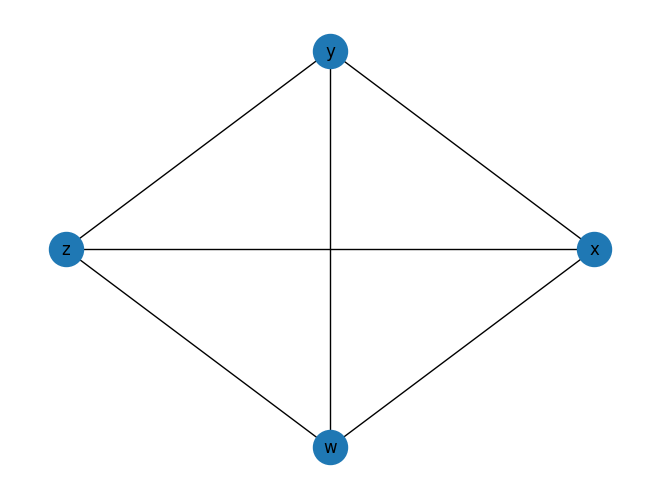

In [7]:
G = nx.complete_graph(4)
nodes_pos = nx.circular_layout(G)
nx.set_node_attributes(G, labels, "labels")
nx.draw(G, pos=nodes_pos, with_labels=True, node_size=600, labels=nx.get_node_attributes(G, "labels"))